In [1]:
from pathlib import Path

model_dir = Path(r"D:\wuzm\models\Z-Image-Turbo-int4-ov")

from notebook_utils import device_widget

device = device_widget(default="AUTO", exclude=["NPU"])
device

Dropdown(description='Device:', index=2, options=('CPU', 'GPU', 'AUTO'), value='AUTO')

In [2]:
from optimum.intel import OVZImagePipeline

ov_pipe = OVZImagePipeline.from_pretrained(model_dir, device=device.value)
print("✅ 模型加载完成")

Task was destroyed but it is pending!
task: <Task pending name='Task-30' coro=<_async_in_context.<locals>.run_in_context() done, defined at D:\Software\anaconda3\envs\openvino\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-31' coro=<Kernel.shell_main() running at D:\Software\anaconda3\envs\openvino\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at D:\Software\anaconda3\envs\openvino\Lib\site-packages\zmq\eventloop\zmqstream.py:563]>
D:\Software\anaconda3\envs\openvino\Lib\site-packages\transformers\utils\__init__.py:19: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  from huggingface_hub import get_full_repo_name  # for backward compatibility
Task was destroyed but it is pending!
task: <Task pending name='Task-31' coro=<Kernel.shell_main() running at D:\Software\anaconda3\envs\openvino\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]>
Multiple d

✅ 模型加载完成


  0%|          | 0/9 [00:00<?, ?it/s]

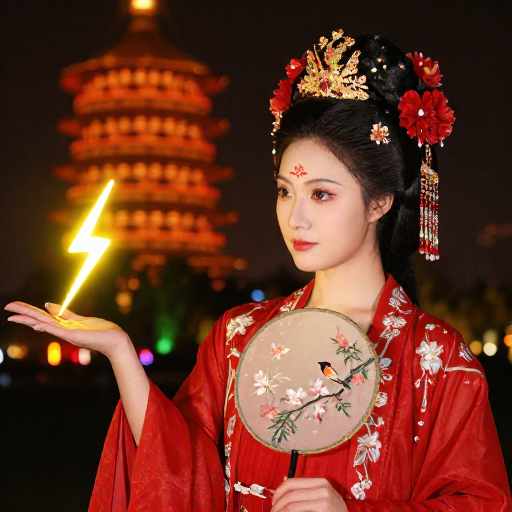

In [3]:
import torch

prompt = "Young Chinese woman in red Hanfu, intricate embroidery. Impeccable makeup, red floral forehead pattern. Elaborate high bun, golden phoenix headdress, red flowers, beads. Holds round folding fan with lady, trees, bird. Neon lightning-bolt lamp, bright yellow glow, above extended left palm. Soft-lit outdoor night background, silhouetted tiered pagoda, blurred colorful distant lights."

image = ov_pipe(
    prompt=prompt,
    height=512,
    width=512,
    num_inference_steps=9,
    guidance_scale=0.0,
    generator=torch.Generator("cpu").manual_seed(42),
).images[0]

image

In [5]:
ov_pipe

OVZImagePipeline {
  "_class_name": "OVZImagePipeline",
  "_diffusers_version": "0.36.0.dev0",
  "_name_or_path": "Tongyi-MAI/Z-Image-Turbo",
  "scheduler": [
    "diffusers",
    "FlowMatchEulerDiscreteScheduler"
  ],
  "text_encoder": [
    "optimum.intel.openvino.modeling_diffusion",
    "OVModelTextEncoder"
  ],
  "tokenizer": [
    "transformers",
    "Qwen2Tokenizer"
  ],
  "transformer": [
    "optimum.intel.openvino.modeling_diffusion",
    "OVModelTransformer"
  ],
  "vae": [
    "optimum.intel.openvino.modeling_diffusion",
    "OVModelVae"
  ]
}

In [ ]:
from gradio_helper_zimage import make_demo

demo = make_demo(ov_pipe)

try:
    demo.launch(debug=True)
except Exception:
    demo.launch(debug=True, share=True)

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
